In [1]:
import cx_Oracle
cx_Oracle.init_oracle_client(lib_dir=r"C:\oracle\instantclient_19_9")
from datetime import datetime, time
import pandas as pd
import numpy as np
from Database.TPData import TPData
from Math.ti_class import TI_class
from RiskPremium.RP_Tools import TP_trades_data


In [2]:
data_class = TPData()

mkt_list = ['de']
tenor_list = ['m']
tn_list = [1]
prod = 'base'
venue_list = ['eex']
start_date = datetime(2023, 6, 12)
end_date = datetime(2023, 9, 1)
n_s = 2

In [25]:
data_class = TPData()

mkt_list = ['de']
tenor_list = ['m']
tn_list = [1]
prod = 'base'
venue_list = ['eex']
start_date = datetime(2023, 6, 12)
end_date = datetime(2023, 9, 1)
n_s = 2

dates = pd.date_range(start_date, end_date, freq='B')
product_date = [dates.shift(1, freq='B') if t == 'da' else
                dates.shift(1, freq='D') if t == 'd' else
                dates.shift(tn, freq='W-MON') if t == 'w' else
                (dates + n_s * dates.freq).shift(tn, freq='2QS-Apr') if t in ['sum', 'win'] else
                (dates + n_s * dates.freq).shift(tn, freq='YS') if t in ['dec'] else
                (dates + n_s * dates.freq).shift(tn, freq=t.upper() + 'S')
                for t, tn in zip(tenor_list, tn_list)]


start_time = time(8, 0, 0)
end_time = time(18, 0, 0)

tr_data_dict = {m + t + str(n): [] for m, t, n in zip(mkt_list, tenor_list, tn_list)}
agg_dict = {'price': 'mean', 'volume': 'sum', 'action': 'first', 'broker_id': 'first'}

for m, t, n, p_dates in zip(mkt_list, tenor_list, tn_list, product_date):
    df_tr = pd.DataFrame([])
    series = pd.Series(p_dates, index=dates)
    for p_d, ds in series.groupby(series).groups.items():
        bT = datetime.combine(ds[0], start_time)
        eT = datetime.combine(ds[-1], end_time)
        # Trades
        data_class.create_connection('OracleSQL')
        df_tr_aux = data_class.get_trades(m, t, venue_list, p_d, bT, eT, prod)
        try:
            df_tr_aux = df_tr_aux.between_time(start_time, end_time)
        except(TypeError):
            pass
        #df_tr_aux = data_class.filter_data(df_tr_aux, df_tr_aux['price'], 20)
        df_tr = pd.concat([df_tr, df_tr_aux])
    df_tr = data_class.filter_data(df_tr, df_tr['price'], 20)
    df_tr = df_tr.groupby(df_tr.index).agg(agg_dict)
    tr_data_dict[m + t + str(n)] = df_tr

data_p = pd.concat({k: v['price'] for k, v in tr_data_dict.items()}, axis=1)

Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle
Connected to the database oracle
Disconnected from the database oracle


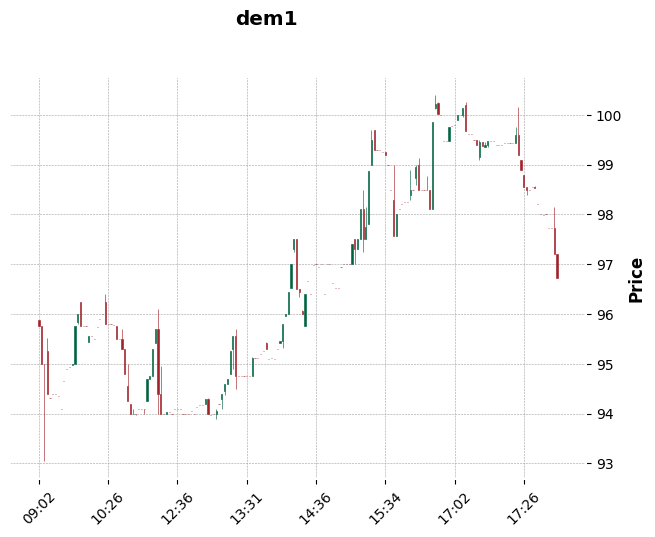

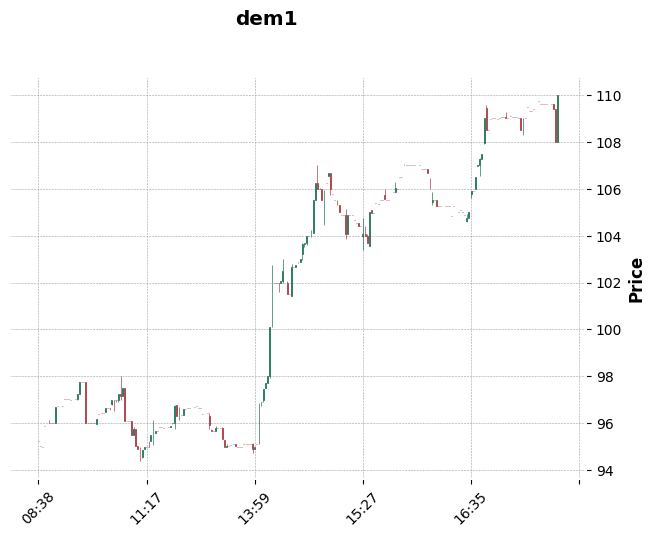

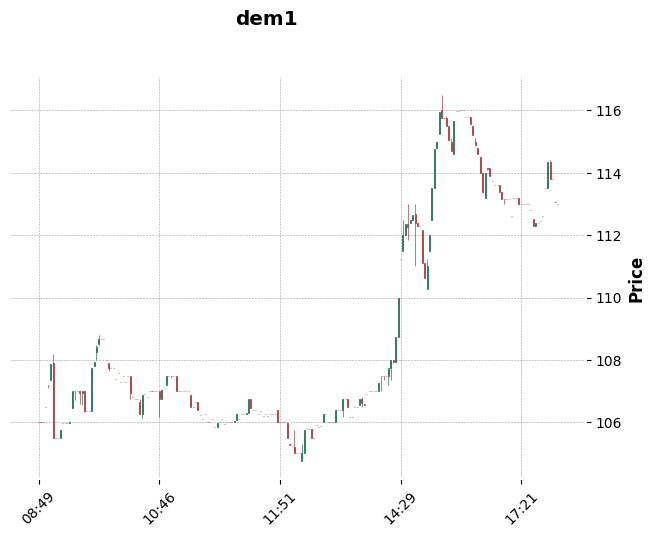

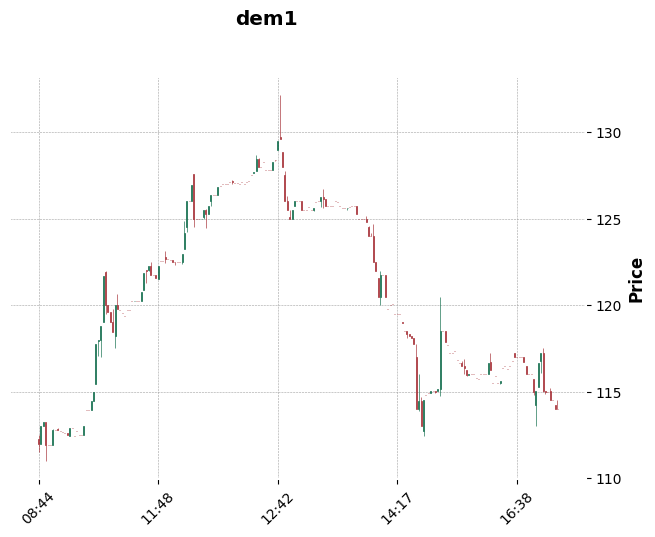

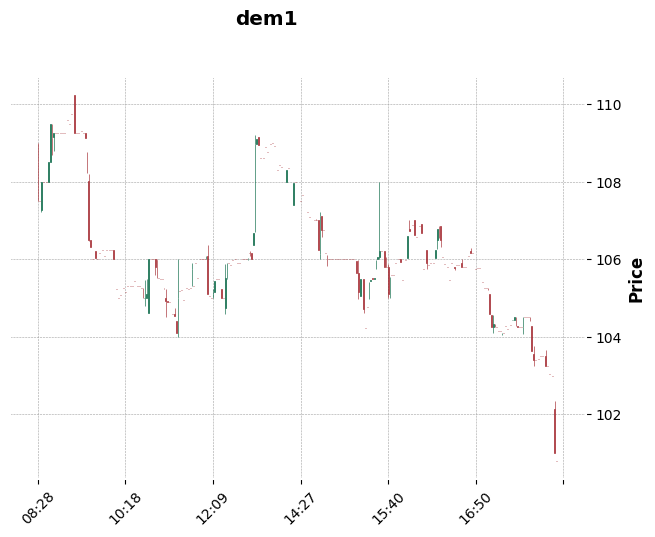

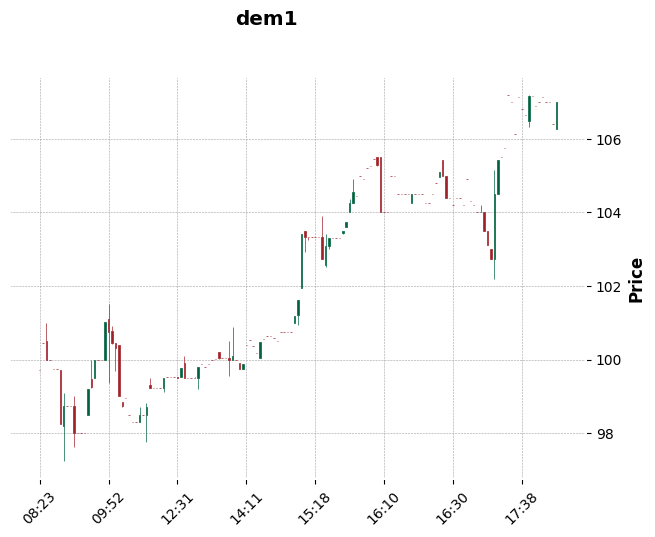

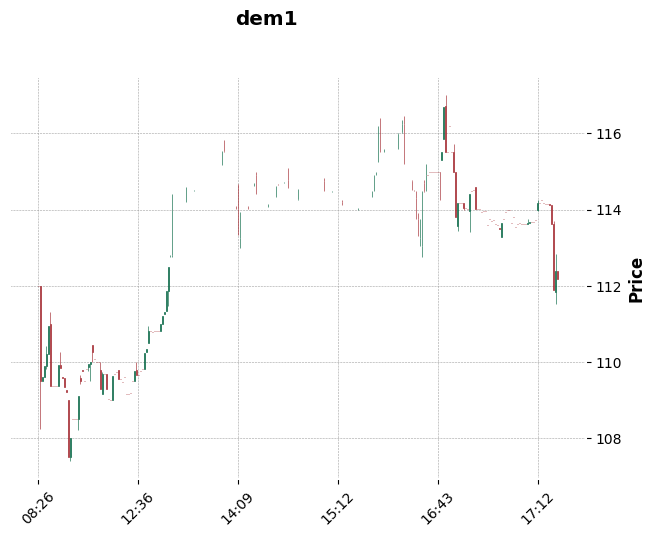

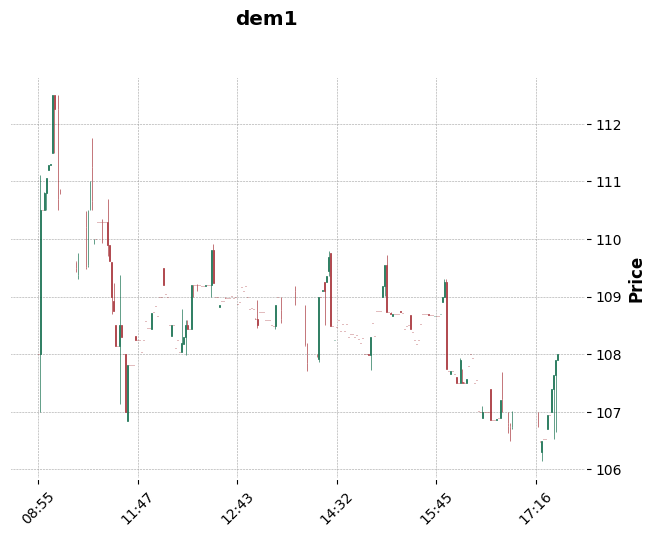

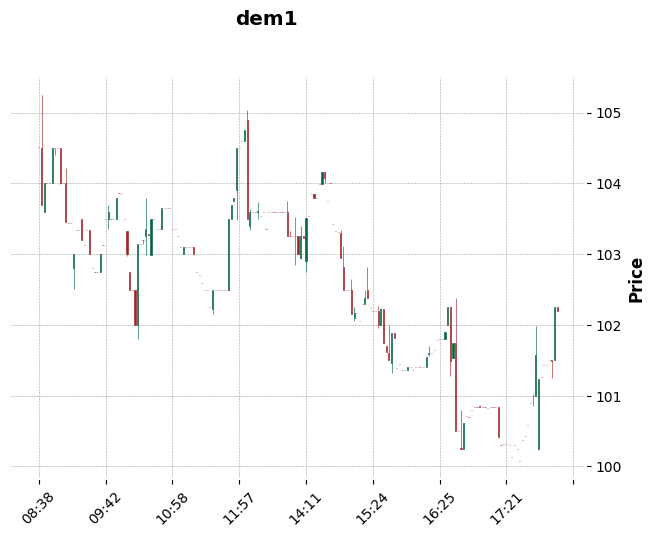

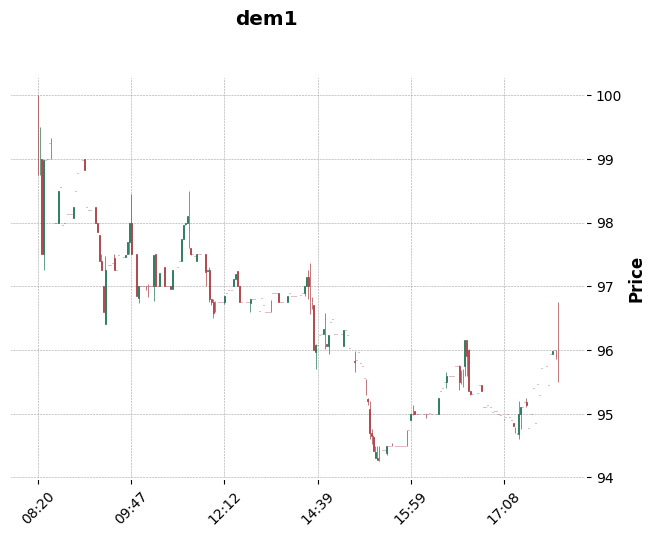

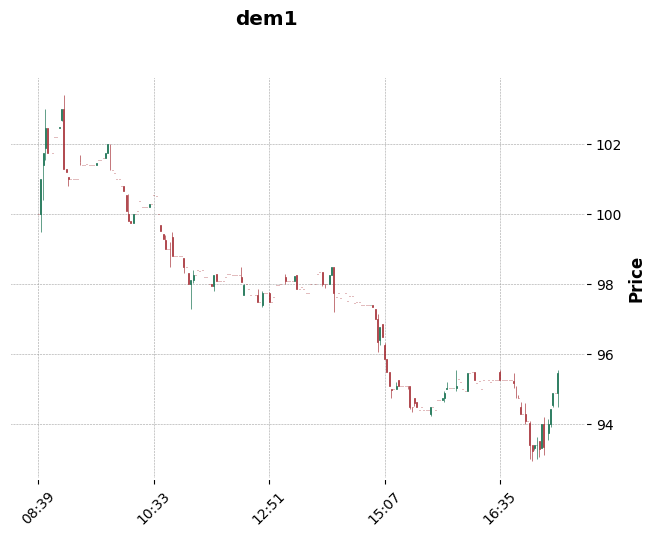

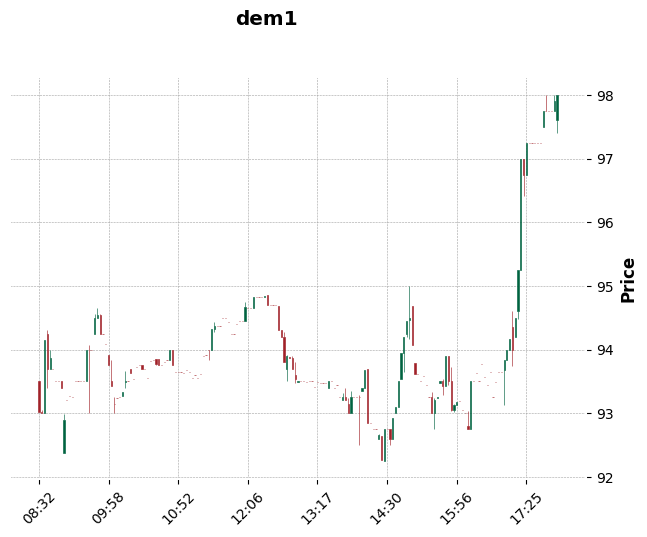

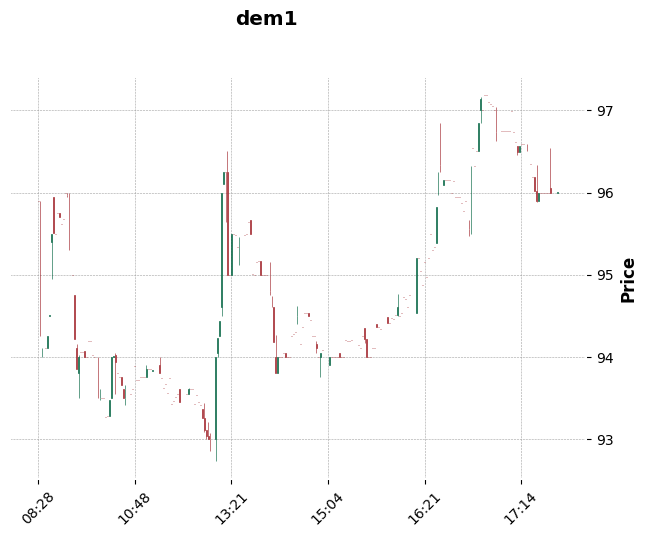

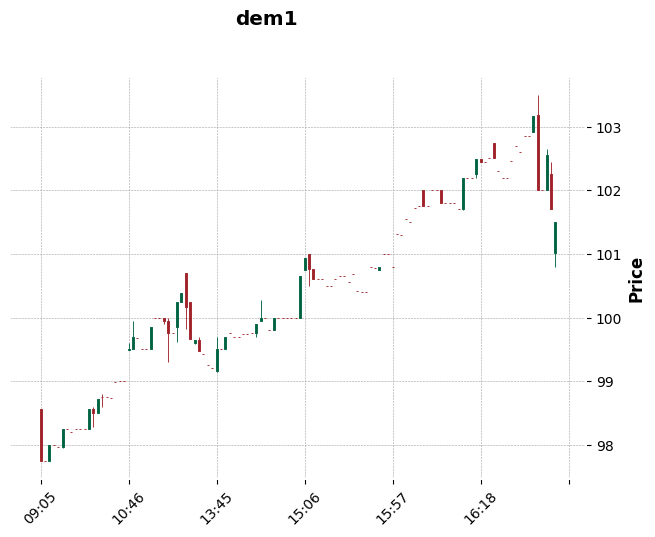

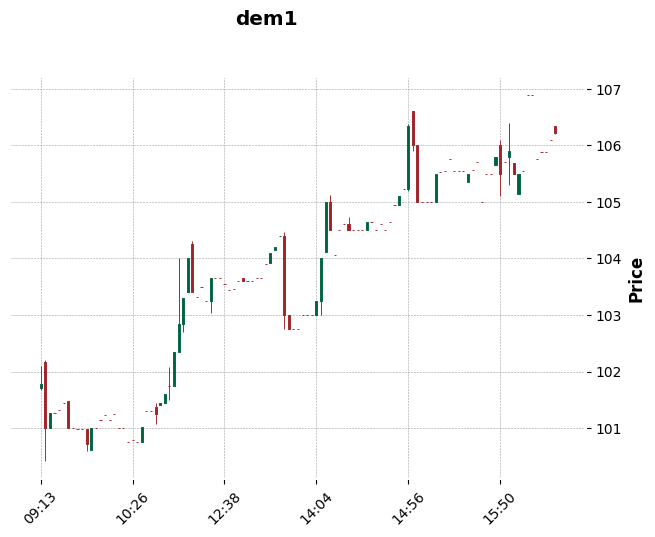

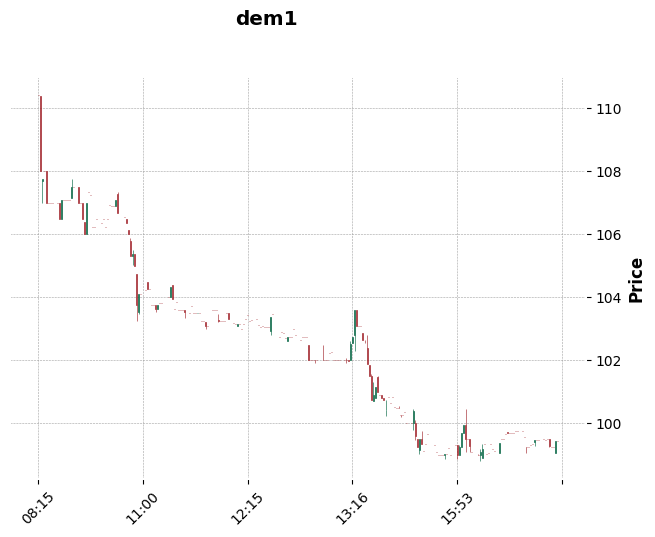

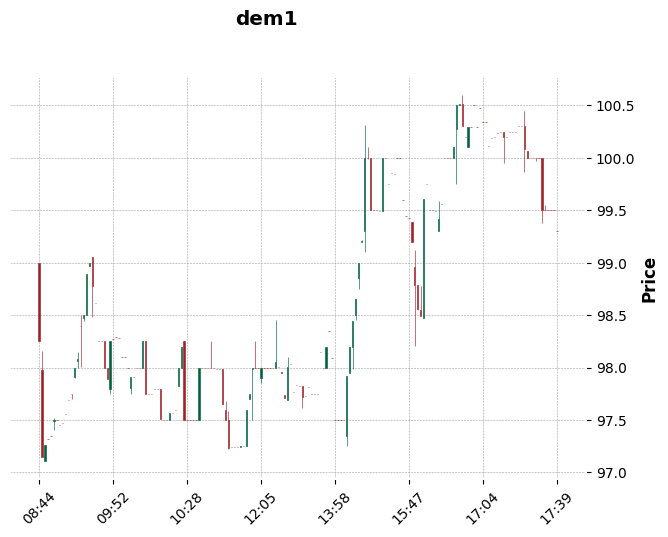

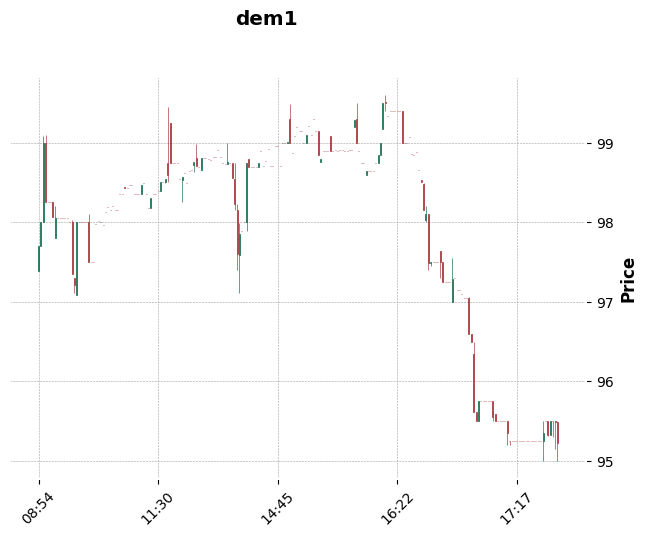

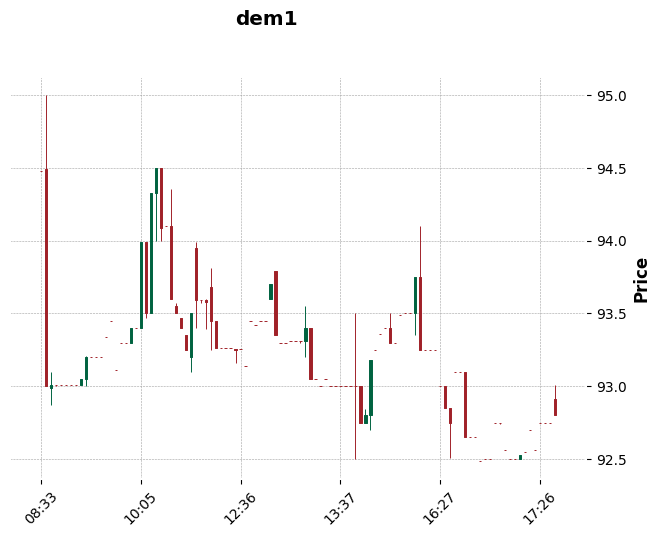

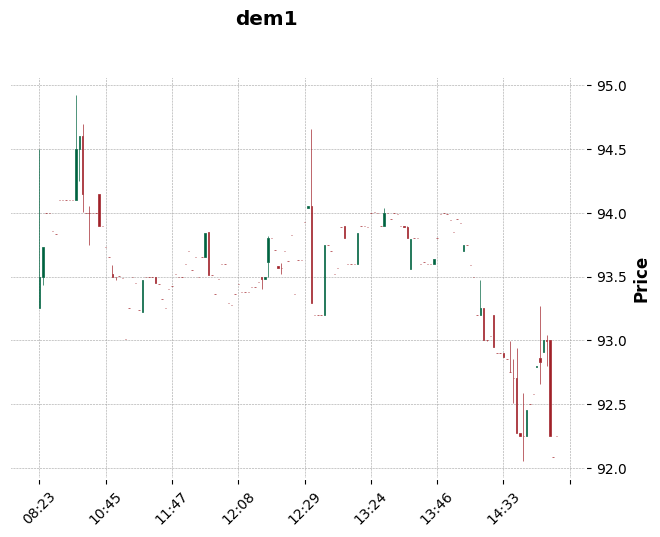

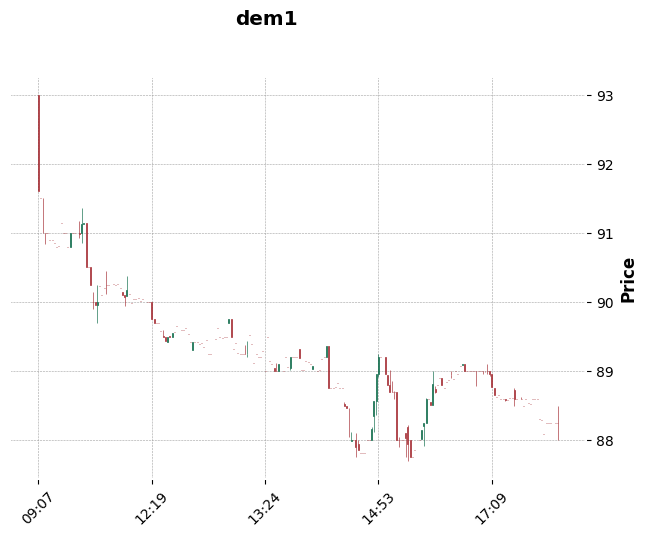

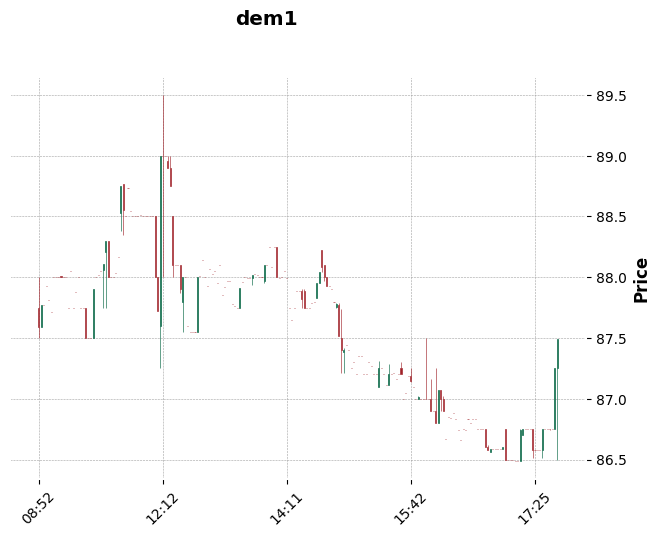

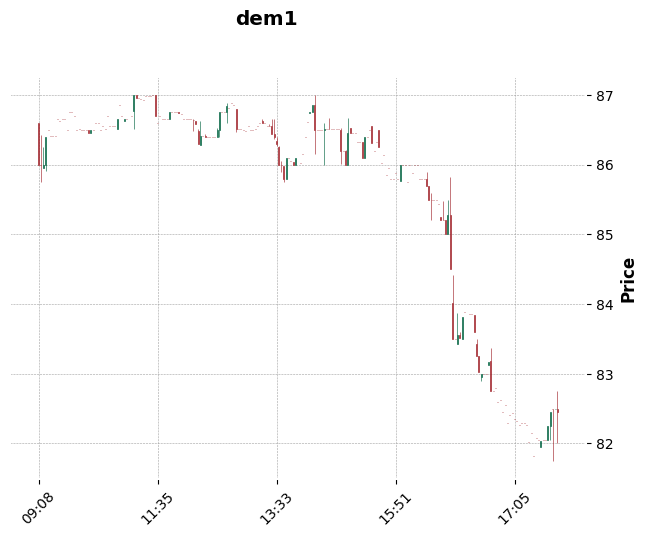

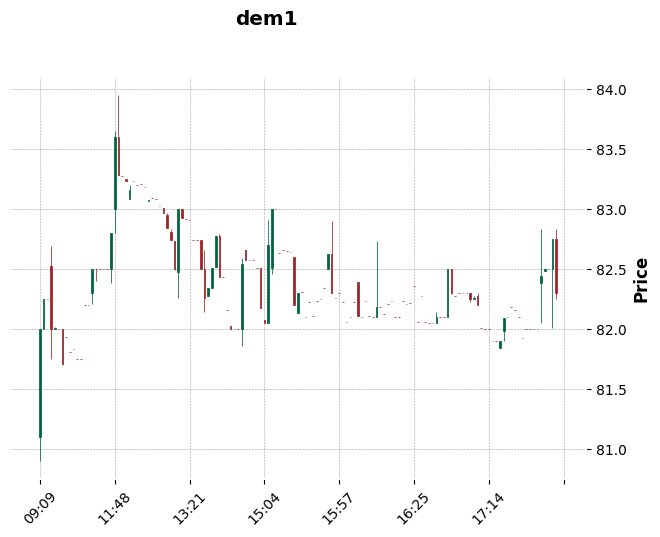

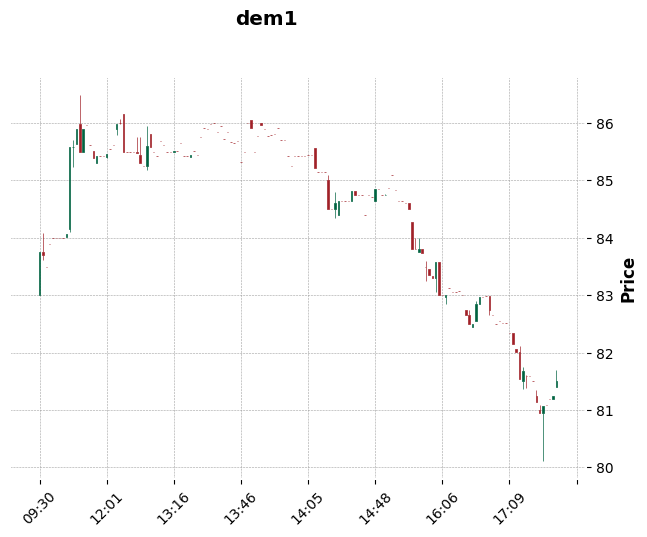

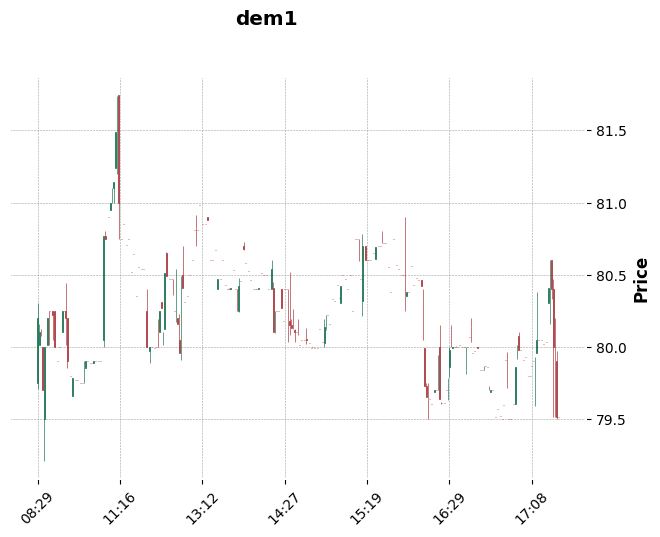

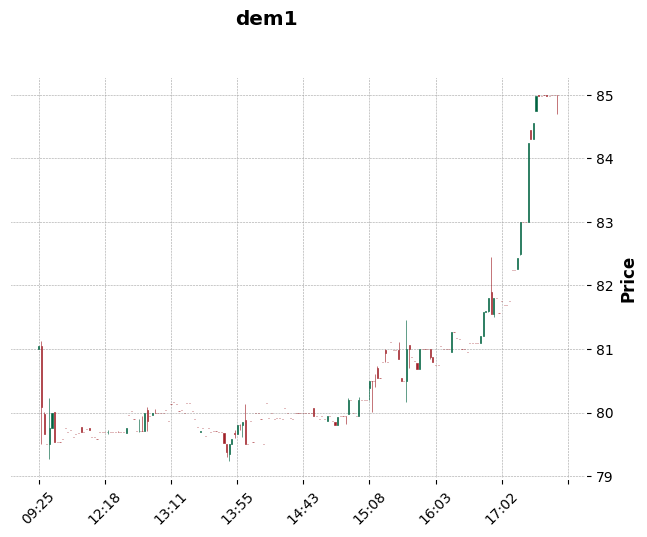

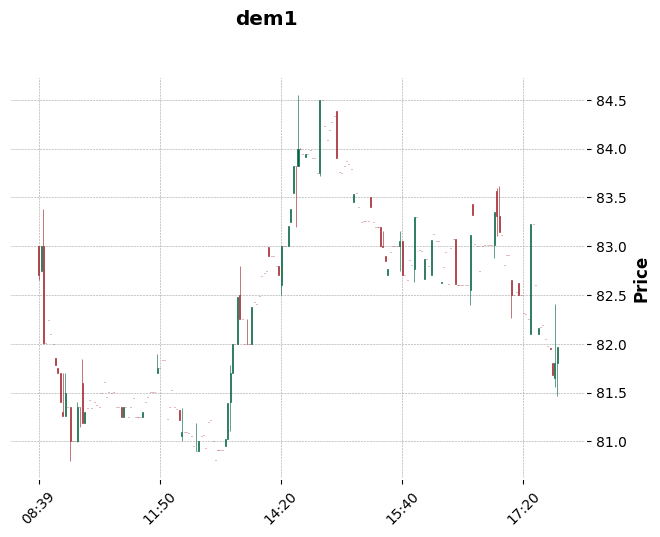

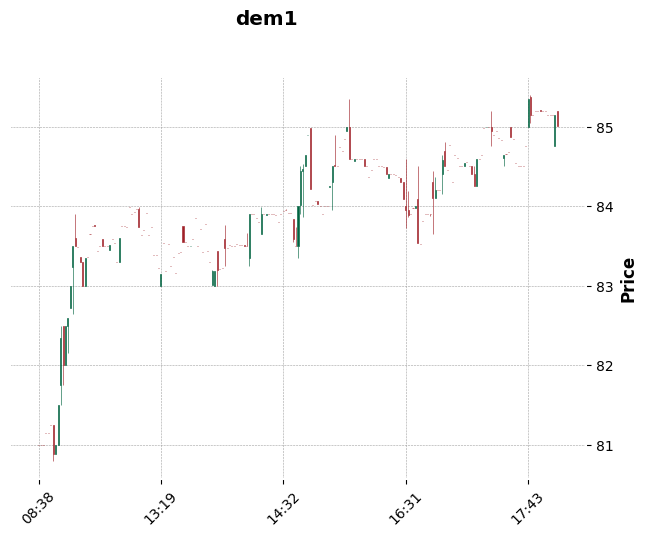

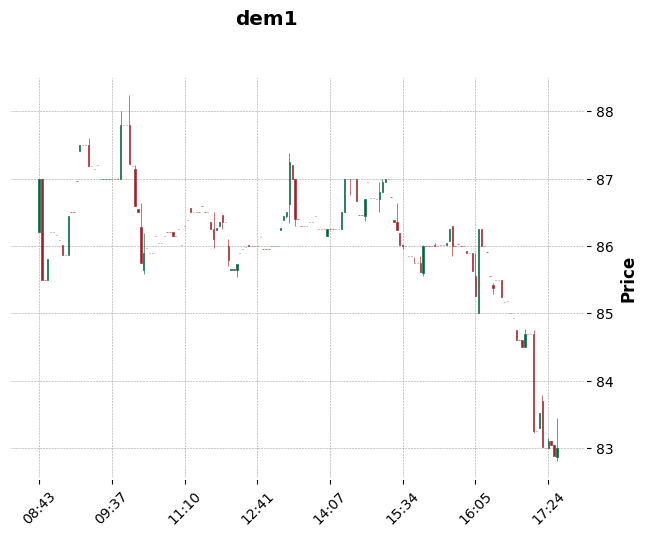

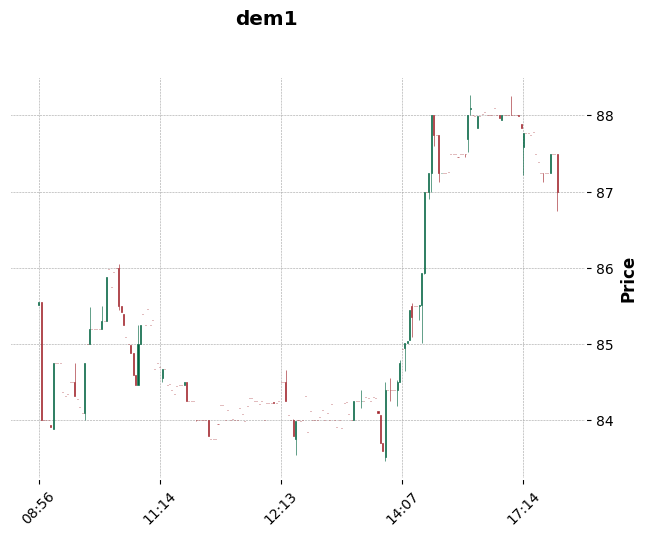

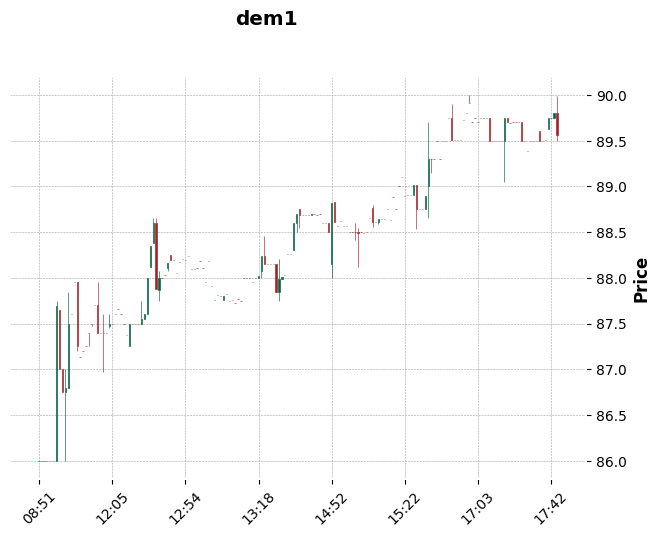

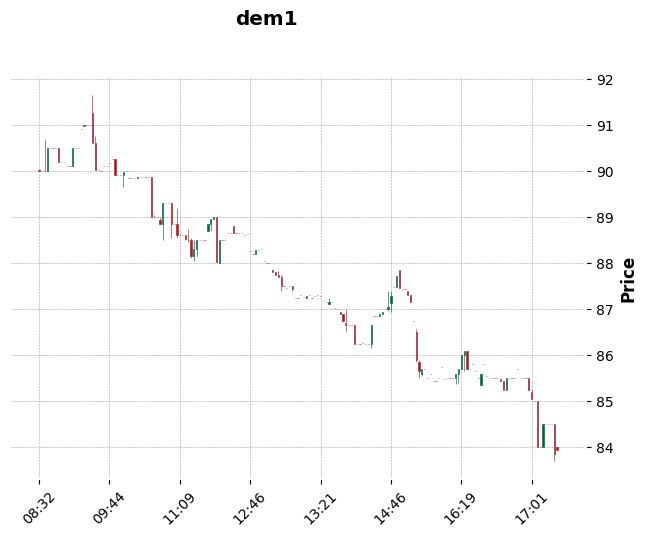

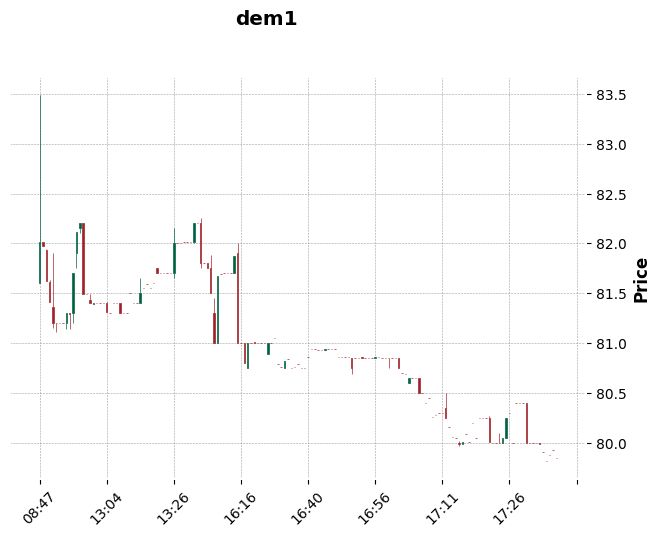

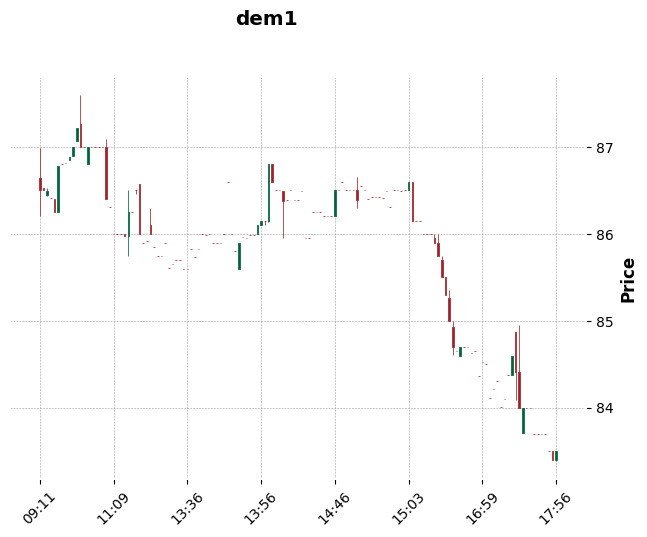

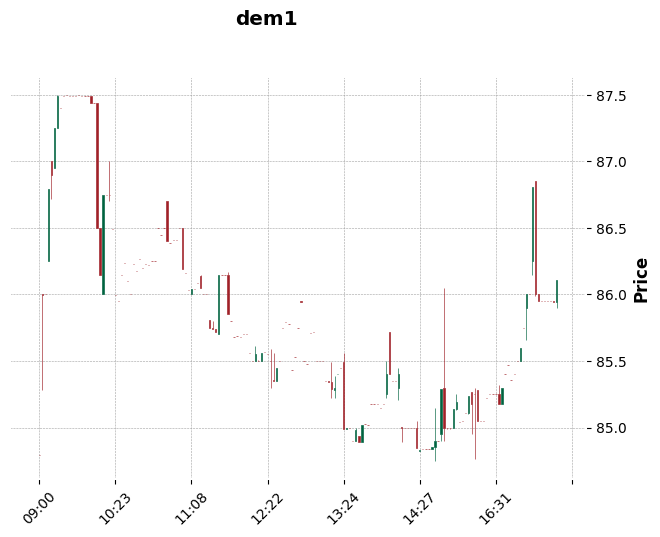

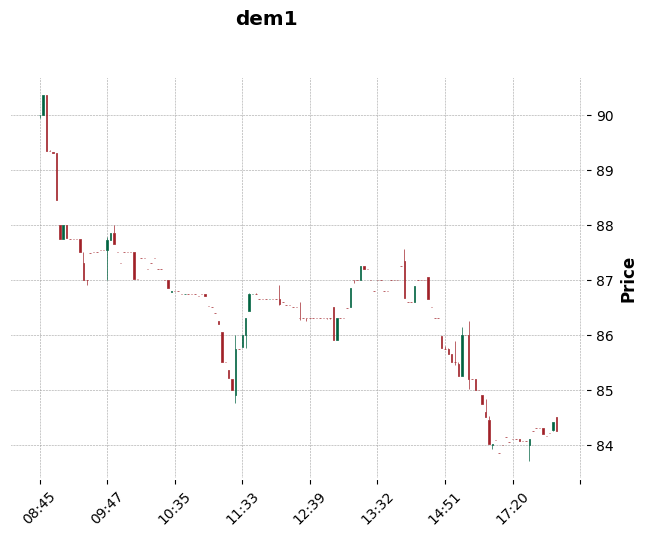

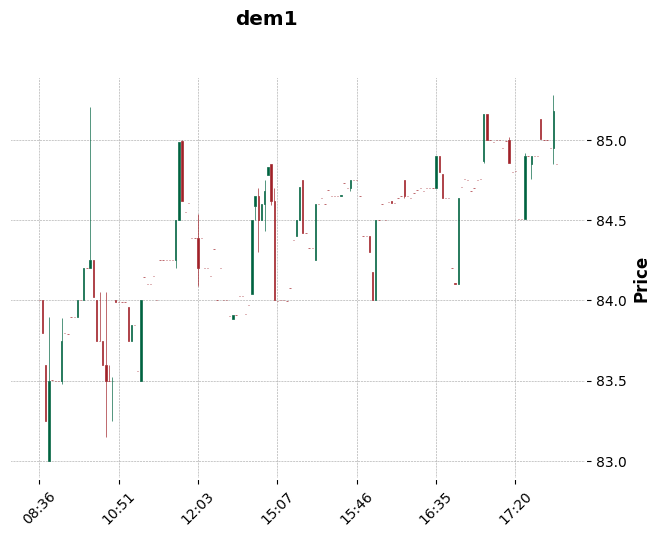

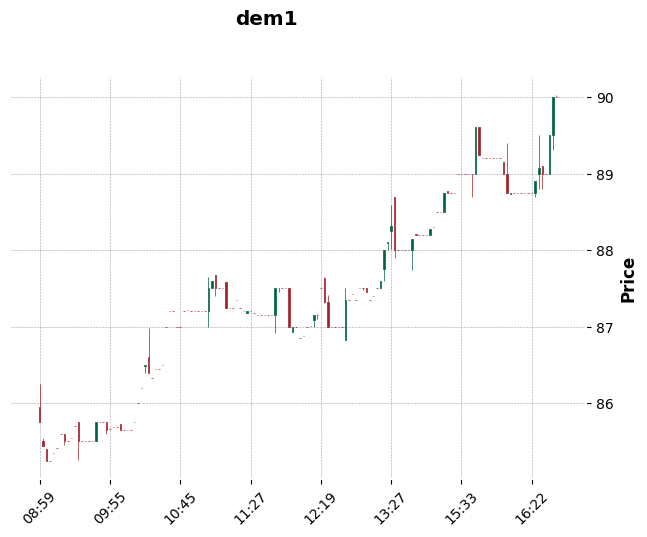

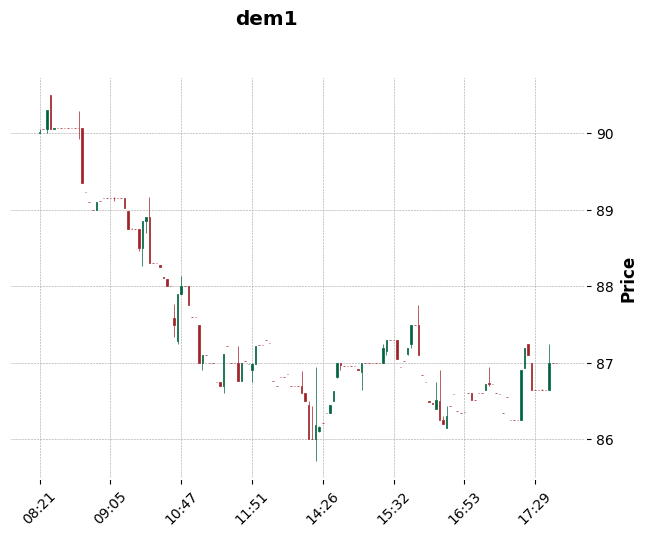

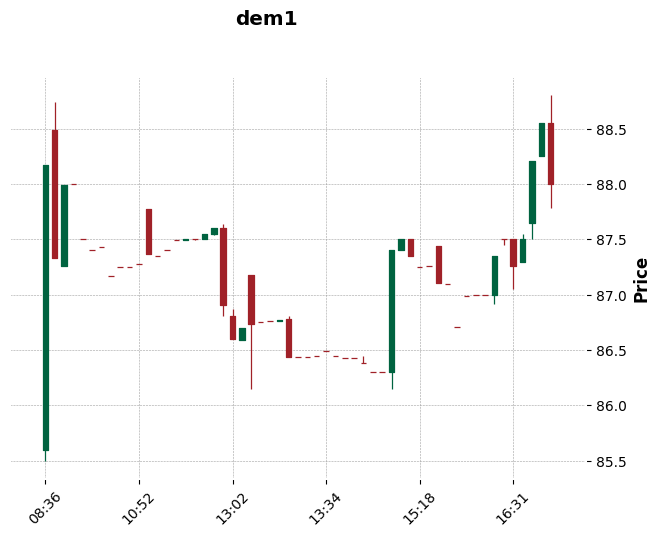

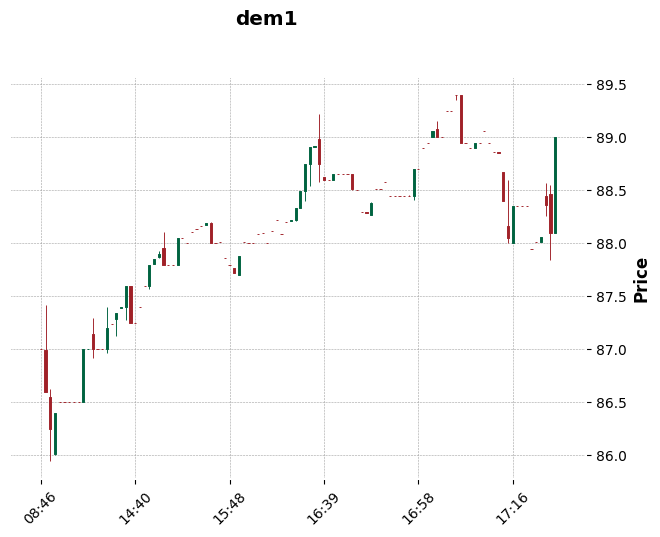

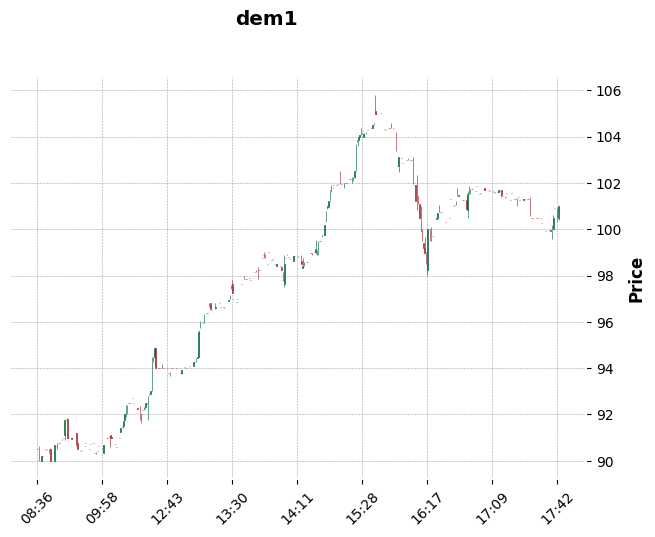

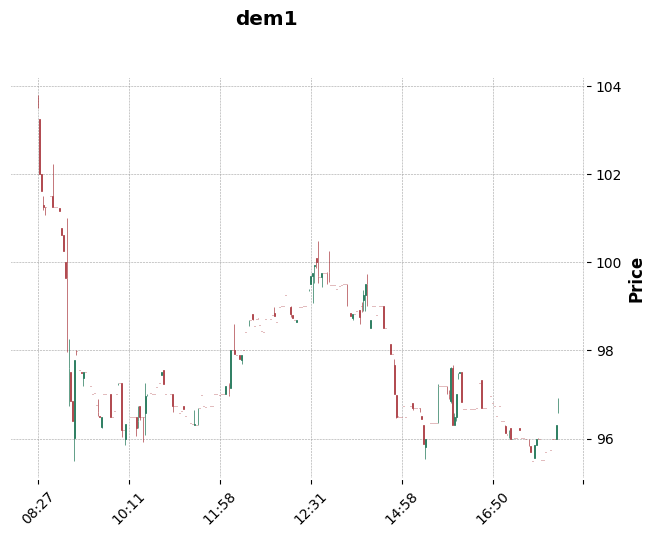

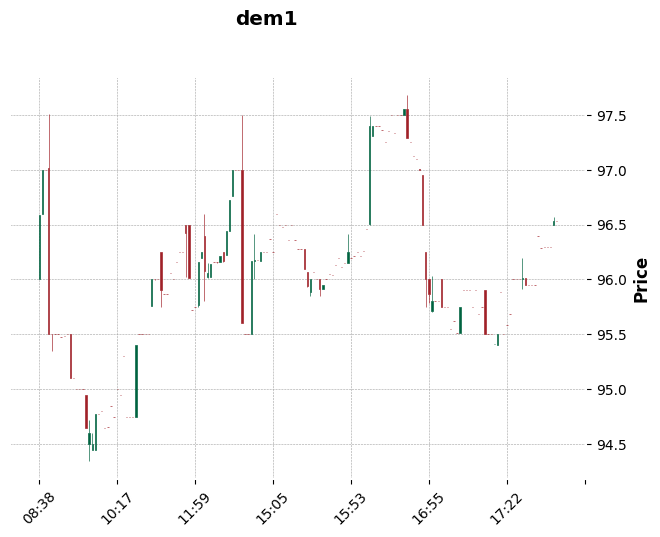

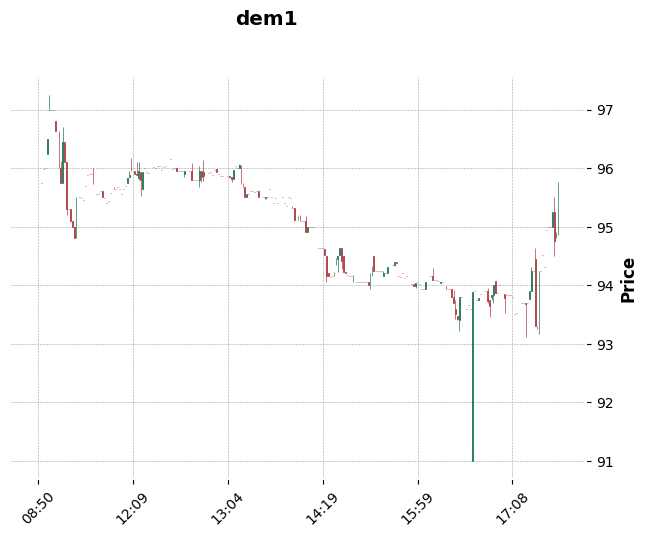

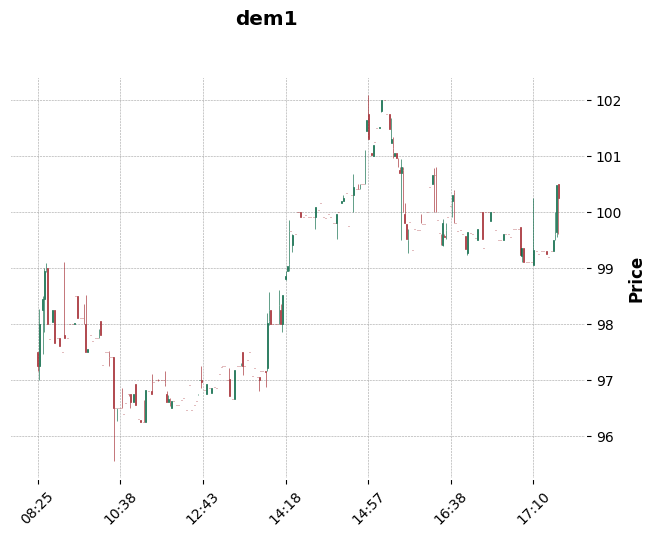

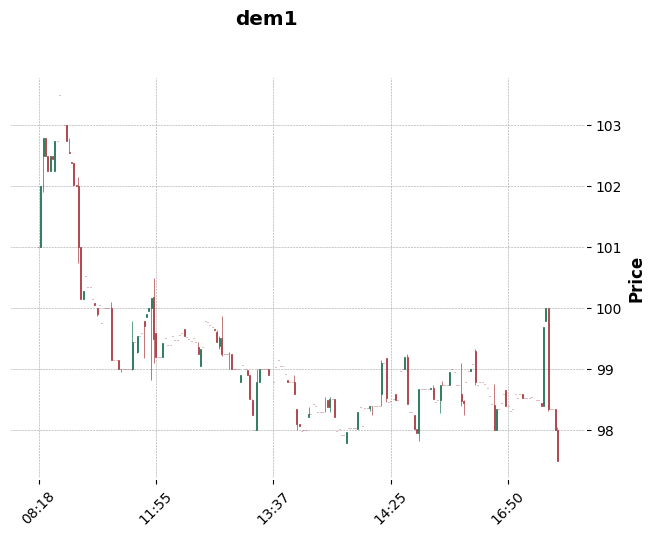

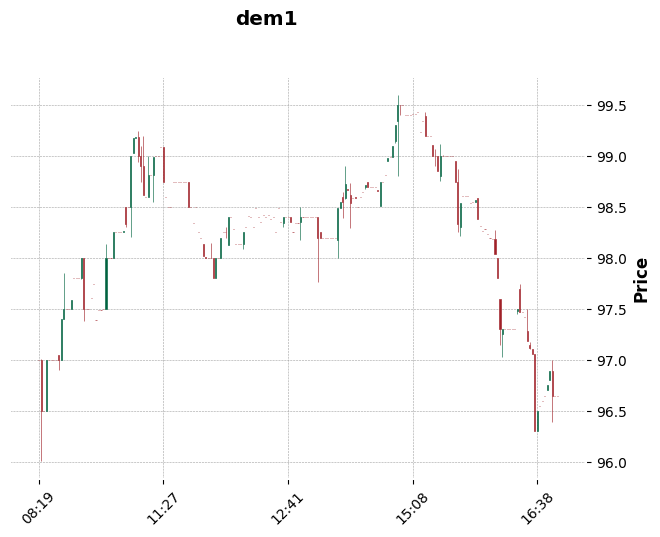

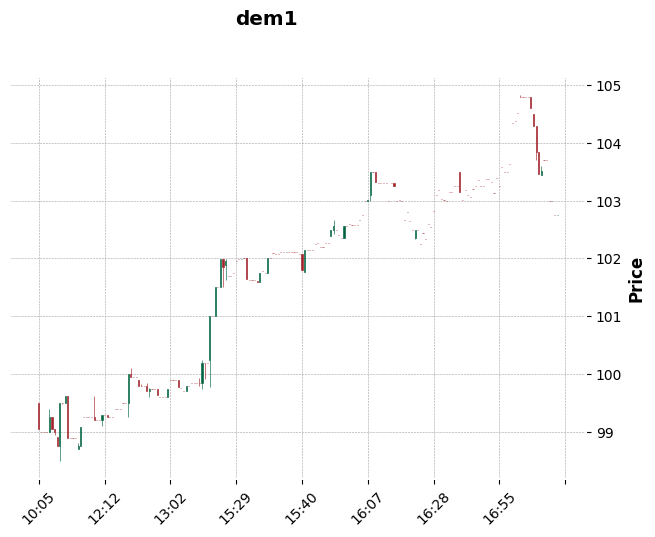

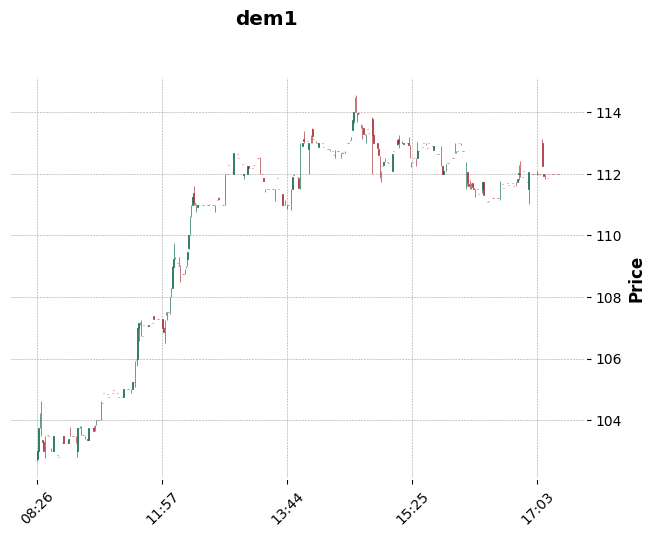

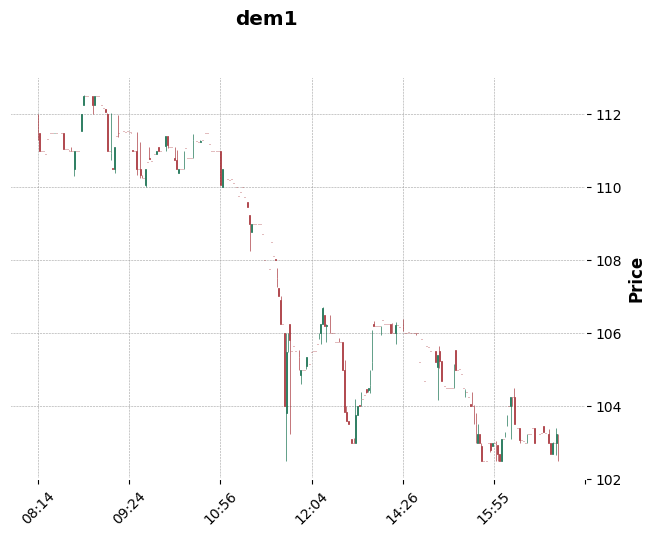

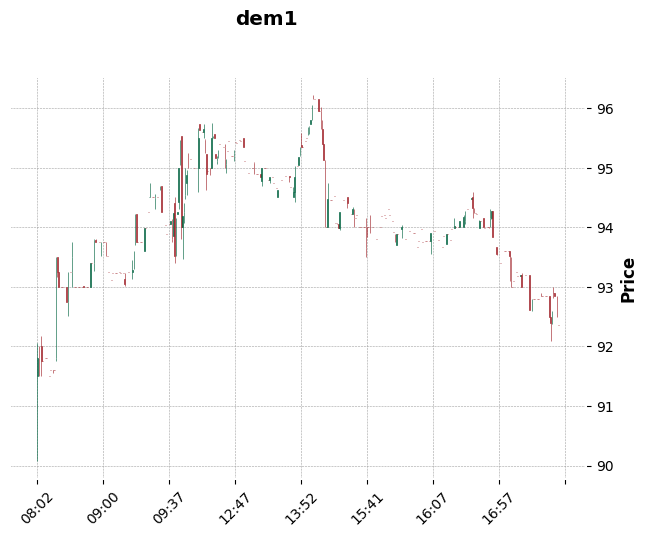

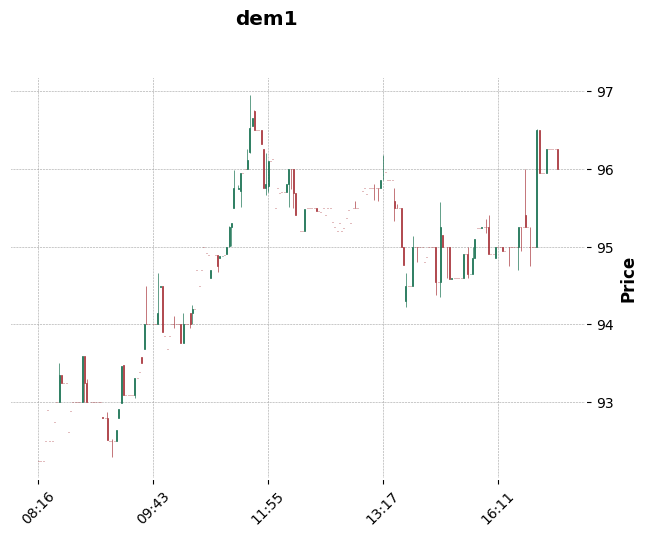

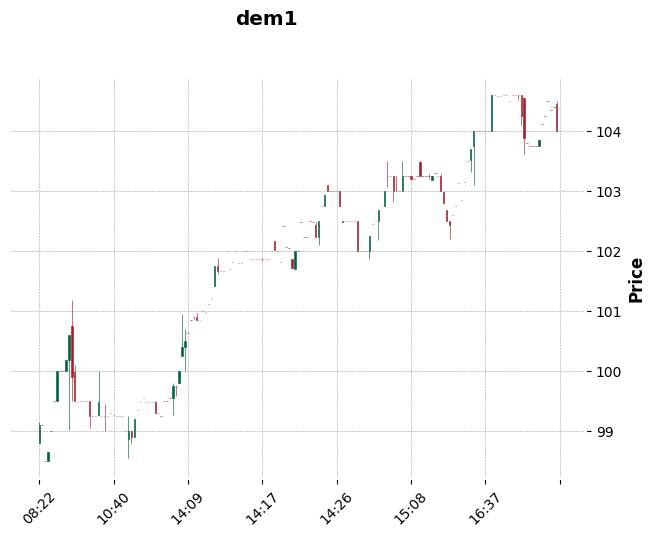

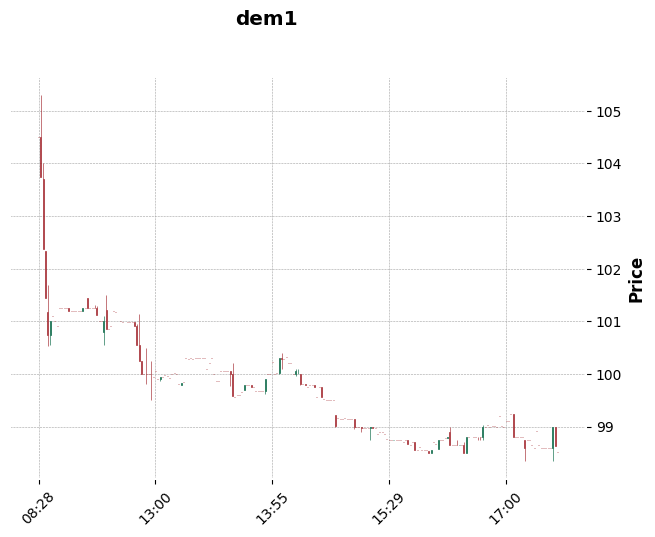

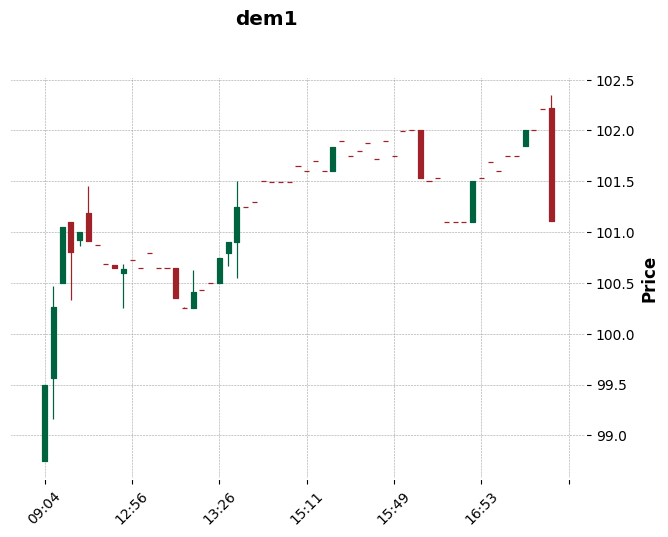

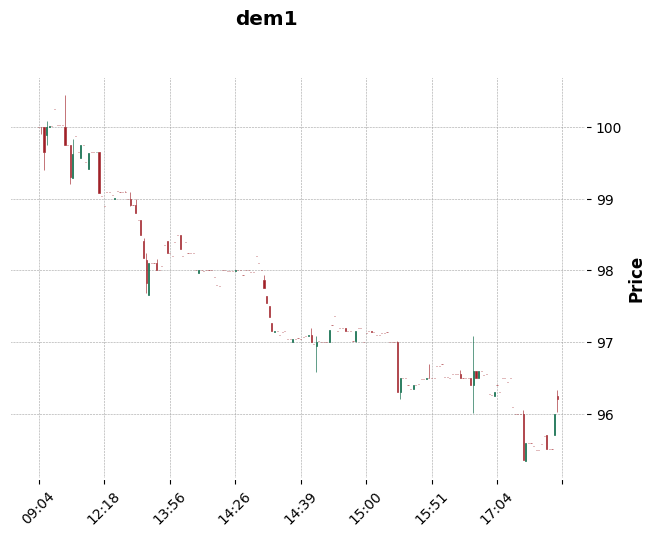

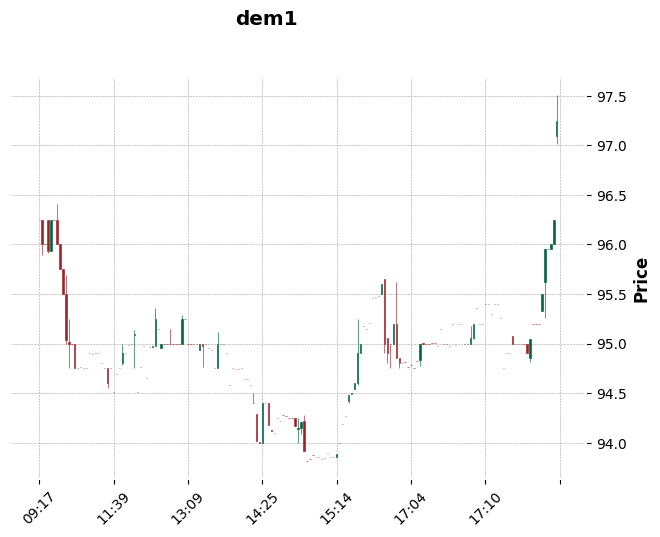

In [26]:
data_p.reset_index(inplace=True)
tau = 10
# EMA
tau_ema = 15
ti_cls = TI_class(tau, tau_ema)

days = data_p['datetime'].dt.date.drop_duplicates()
for day in days:
    trades = data_p[data_p['datetime'].dt.date == day]
    trades.set_index('datetime', inplace=True)
    ti_cls.plot_candles(trades.iloc[:, 0], trades.iloc[:, 0])